# Baseline Models
## Random Note Generator + Markov Chain Music Model



In [1]:
import sys, os, json
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pretty_midi
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from pathlib import Path

from src.config import SPLIT_DIR, PITCH_LOW, PITCH_HIGH, PIANO_ROLL_FS
from src.evaluation.metrics import evaluate_midi, aggregate, print_report

OUTPUTS = Path(PROJECT_ROOT) / 'outputs'
BASELINE_DIR = OUTPUTS / 'generated_midis' / 'baselines'
BASELINE_DIR.mkdir(parents=True, exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Load Training MIDI Files (for Markov training)

In [2]:
train_path = SPLIT_DIR / 'train.json'
if not train_path.exists():
    raise RuntimeError('Run build_dataset.py first!')

all_records = json.loads(train_path.read_text())
# Use MAESTRO only for Markov (single genre, high quality)
maestro_records = [r for r in all_records if r['dataset'] == 'maestro'][:200]
print(f'Using {len(maestro_records)} MAESTRO training files')

Using 200 MAESTRO training files


## 2. Random Note Generator

In [3]:
def generate_random_midi(
    n_notes: int = 64,
    pitch_low: int = PITCH_LOW,
    pitch_high: int = PITCH_HIGH,
    duration: float = 0.25,
    tempo: float = 120.0,
    output_path: str = None
) -> pretty_midi.PrettyMIDI:
    """Uniform random pitch selection — naive baseline."""
    midi = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    inst = pretty_midi.Instrument(program=0)
    t = 0.0
    for _ in range(n_notes):
        pitch = np.random.randint(pitch_low, pitch_high + 1)
        dur   = duration * np.random.choice([0.5, 1.0, 1.5, 2.0])
        inst.notes.append(pretty_midi.Note(velocity=64, pitch=pitch, start=t, end=t + dur))
        t += dur + np.random.uniform(0, 0.1)
    midi.instruments.append(inst)
    if output_path:
        Path(output_path).parent.mkdir(parents=True, exist_ok=True)
        midi.write(output_path)
    return midi

# Generate 5 random samples
rand_dir = BASELINE_DIR / 'random'
rand_dir.mkdir(parents=True, exist_ok=True)
for i in range(5):
    generate_random_midi(output_path=str(rand_dir / f'random_{i+1}.mid'))
print(f'Random samples saved to {rand_dir}')

Random samples saved to d:\Study\425\Project\outputs\generated_midis\baselines\random


## 3. Build Markov Chain from Training Data

In [4]:
class MarkovChain:
    def __init__(self, order: int = 1):
        self.order = order
        # transitions[state] = Counter({next_pitch: count})
        self.transitions  = defaultdict(Counter)
        self.dur_model    = defaultdict(Counter)  # pitch → duration distribution
        self.start_pitches = Counter()

    def train(self, midi_paths: list) -> None:
        """Learn transition probabilities from a list of MIDI files."""
        n_trained = 0
        for path in midi_paths:
            try:
                midi  = pretty_midi.PrettyMIDI(path)
                notes = sorted(
                    [n for inst in midi.instruments if not inst.is_drum
                       for n in inst.notes],
                    key=lambda n: n.start
                )
                if len(notes) < self.order + 1:
                    continue
                pitches   = [n.pitch for n in notes]
                # Quantise to nearest 50 ms (spec requirement)
                durations = [round(round((n.end - n.start) / 0.05) * 0.05, 10) for n in notes]

                # Start pitch distribution
                self.start_pitches[pitches[0]] += 1

                # Transitions
                for i in range(len(pitches) - self.order):
                    state = tuple(pitches[i : i + self.order])
                    nxt   = pitches[i + self.order]
                    self.transitions[state][nxt] += 1

                # Duration model
                for p, d in zip(pitches, durations):
                    self.dur_model[p][d] += 1

                n_trained += 1
            except Exception:
                continue
        print(f'Trained on {n_trained} files | {len(self.transitions)} unique states')

    def _sample_next(self, state: tuple) -> int:
        """Sample next pitch given state. Falls back to start distribution."""
        if state in self.transitions:
            ctr = self.transitions[state]
        elif self.start_pitches:
            ctr = self.start_pitches
        else:
            return np.random.randint(PITCH_LOW, PITCH_HIGH + 1)
        pitches = list(ctr.keys())
        counts  = np.array(list(ctr.values()), dtype=float)
        counts /= counts.sum()
        return np.random.choice(pitches, p=counts)

    def _sample_duration(self, pitch: int) -> float:
        if pitch in self.dur_model and self.dur_model[pitch]:
            durs   = list(self.dur_model[pitch].keys())
            counts = np.array(list(self.dur_model[pitch].values()), dtype=float)
            counts /= counts.sum()
            return float(np.random.choice(durs, p=counts))
        return 0.25

    def generate(
        self,
        n_notes: int    = 64,
        tempo:   float  = 120.0,
        output_path: str = None
    ) -> pretty_midi.PrettyMIDI:
        """Generate a MIDI sequence using the learned Markov chain."""
        midi = pretty_midi.PrettyMIDI(initial_tempo=tempo)
        inst = pretty_midi.Instrument(program=0)

        # Initialise from start distribution
        if self.start_pitches:
            sp = list(self.start_pitches.keys())
            sc = np.array(list(self.start_pitches.values()), dtype=float); sc /= sc.sum()
            history = [int(np.random.choice(sp, p=sc)) for _ in range(self.order)]
        else:
            history = [np.random.randint(PITCH_LOW, PITCH_HIGH + 1) for _ in range(self.order)]

        t = 0.0
        for _ in range(n_notes):
            pitch = history[-1]
            dur   = self._sample_duration(pitch)
            inst.notes.append(pretty_midi.Note(velocity=72, pitch=pitch, start=t, end=t + dur))
            t += dur

            state = tuple(history[-self.order:])
            nxt   = self._sample_next(state)
            history.append(nxt)

        midi.instruments.append(inst)
        if output_path:
            Path(output_path).parent.mkdir(parents=True, exist_ok=True)
            midi.write(output_path)
        return midi


# Train 1st-order Markov chain
mc1 = MarkovChain(order=1)
mc1.train([r['path'] for r in maestro_records])

Trained on 200 files | 88 unique states


In [5]:
# Train 2nd-order Markov chain
mc2 = MarkovChain(order=2)
mc2.train([r['path'] for r in maestro_records])

Trained on 200 files | 6725 unique states


## 4. Generate Markov Samples

In [6]:
mc1_dir = BASELINE_DIR / 'markov_order1'
mc2_dir = BASELINE_DIR / 'markov_order2'
mc1_dir.mkdir(parents=True, exist_ok=True)
mc2_dir.mkdir(parents=True, exist_ok=True)

for i in range(5):
    mc1.generate(n_notes=128, output_path=str(mc1_dir / f'markov1_{i+1}.mid'))
    mc2.generate(n_notes=128, output_path=str(mc2_dir / f'markov2_{i+1}.mid'))

print(f'1st-order Markov samples → {mc1_dir}')
print(f'2nd-order Markov samples → {mc2_dir}')

1st-order Markov samples → d:\Study\425\Project\outputs\generated_midis\baselines\markov_order1
2nd-order Markov samples → d:\Study\425\Project\outputs\generated_midis\baselines\markov_order2


## 5. Visualise a Generated Sample (Piano Roll)

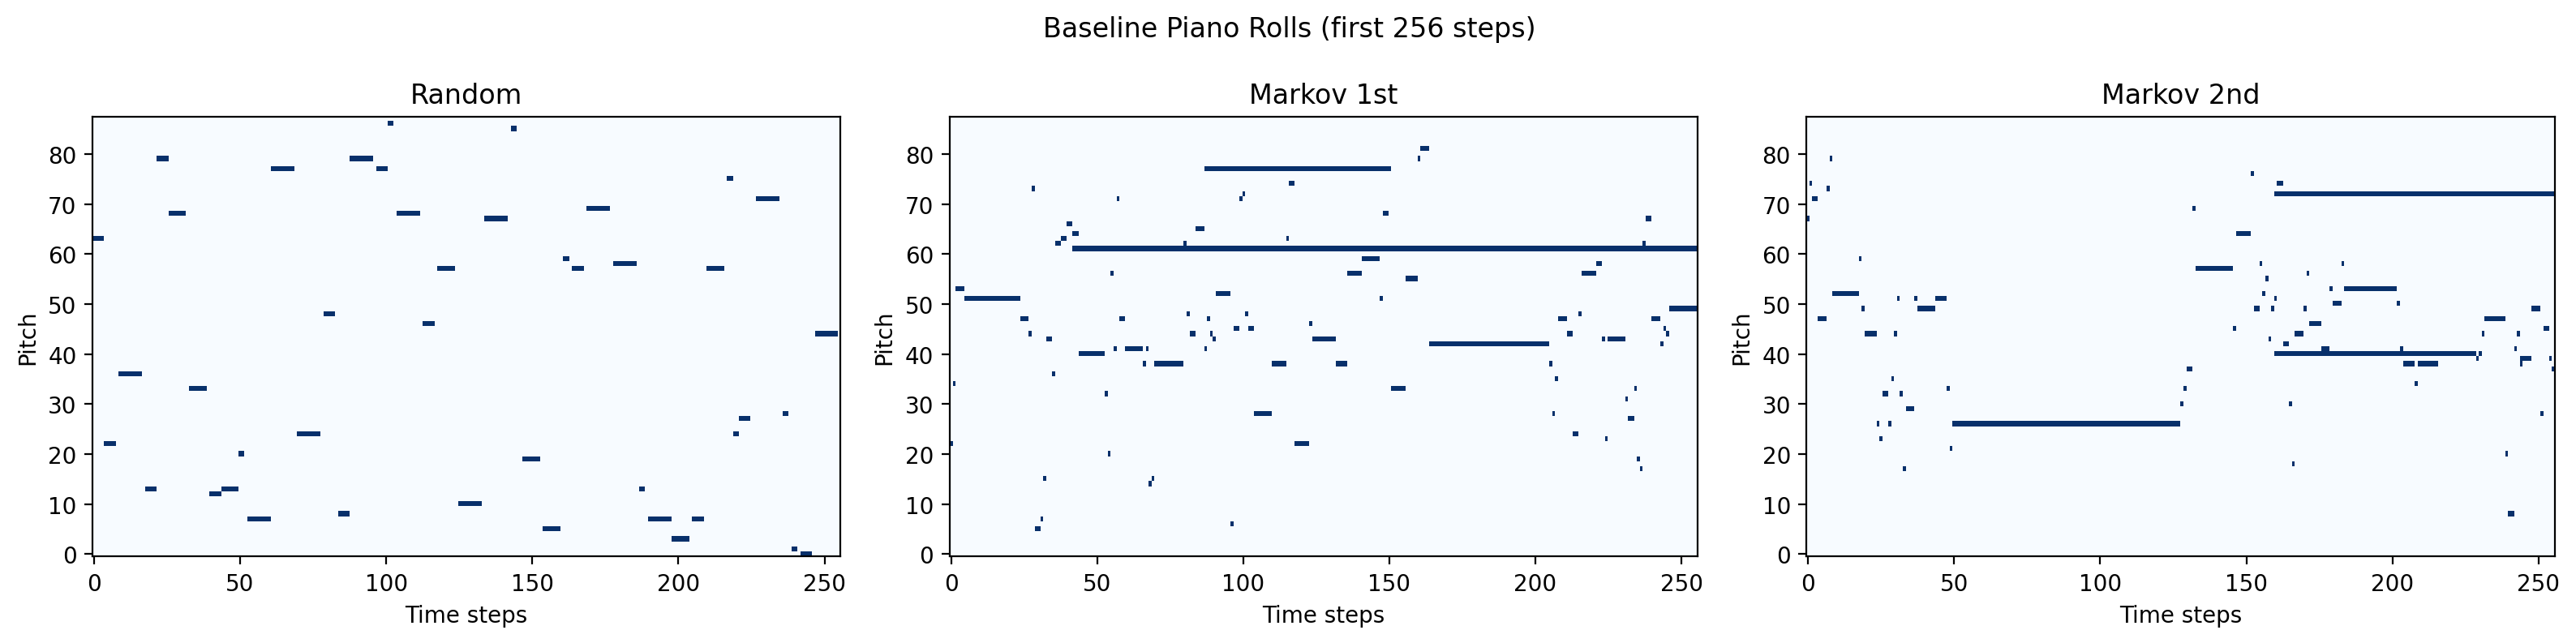

Plot saved.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
titles = [
    ('Random', list(rand_dir.glob('*.mid'))[0]),
    ('Markov 1st', list(mc1_dir.glob('*.mid'))[0]),
    ('Markov 2nd', list(mc2_dir.glob('*.mid'))[0]),
]
for ax, (title, path) in zip(axes, titles):
    midi = pretty_midi.PrettyMIDI(str(path))
    roll = midi.get_piano_roll(fs=PIANO_ROLL_FS)[PITCH_LOW:PITCH_HIGH+1, :256]
    roll = (roll > 0).astype(float)
    ax.imshow(roll, aspect='auto', origin='lower', cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('Time steps')
    ax.set_ylabel('Pitch')
plt.suptitle('Baseline Piano Rolls (first 256 steps)')
plt.tight_layout()
plt.savefig(str(OUTPUTS / 'plots' / 'baseline_piano_rolls.png'), dpi=150)
plt.show()
print('Plot saved.')

## 6. Quantitative Evaluation of Baselines

In [8]:
from src.evaluation.metrics import evaluate_directory, aggregate

# Reference: first MAESTRO val file
val_path = SPLIT_DIR / 'val.json'
val_records = json.loads(val_path.read_text())
maestro_val = [r for r in val_records if r['dataset'] == 'maestro']
reference   = maestro_val[0]['path'] if maestro_val else None
print(f'Reference file: {reference}')

model_dirs = {
    'Random Generator': str(rand_dir),
    'Markov (1st ord)': str(mc1_dir),
    'Markov (2nd ord)': str(mc2_dir),
}

comparison = {}
for name, d in model_dirs.items():
    results = evaluate_directory(d, reference)
    comparison[name] = aggregate(results)

print_report(comparison)

Reference file: d:\Study\425\Project\Dataset\maestro-v3.0.0-midi\maestro-v3.0.0\2006\MIDI-Unprocessed_17_R1_2006_01-06_ORIG_MID--AUDIO_17_R1_2006_04_Track04_wav.midi

Model                       rhythm_diversity          repetition_ratio             pitch_entropy  pitch_histogram_distance
Random Generator                      0.0719                    0.0000                    0.9535                    0.4228
Markov (1st ord)                      0.1337                    0.0000                    0.9800                    0.3691
Markov (2nd ord)                      0.1306                    0.0000                    0.9731                    0.3230



## 7. Save Baseline Metrics

Baseline metrics saved → d:\Study\425\Project\outputs\plots\baseline_metrics.json


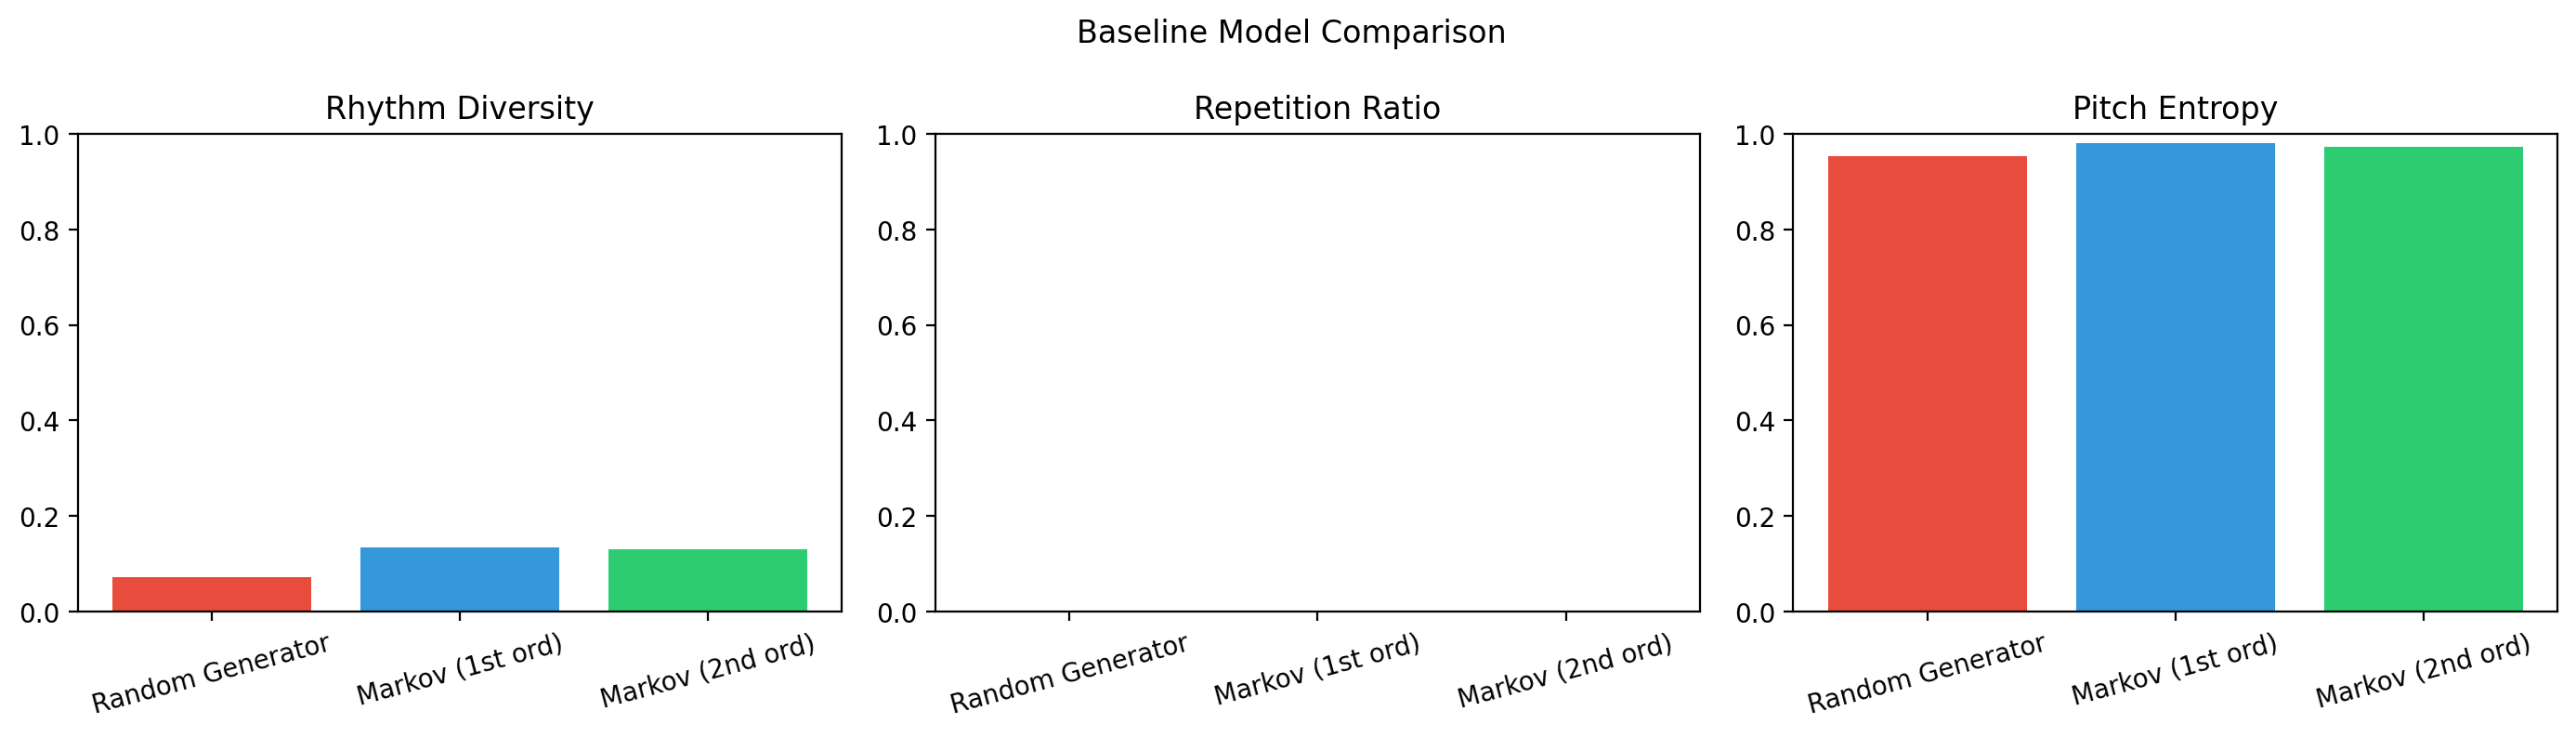

In [9]:
import json
out = OUTPUTS / 'plots' / 'baseline_metrics.json'
out.parent.mkdir(parents=True, exist_ok=True)
out.write_text(json.dumps(comparison, indent=2))
print(f'Baseline metrics saved → {out}')

# Plot comparison bar chart
metrics_to_plot = ['rhythm_diversity', 'repetition_ratio', 'pitch_entropy']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, metrics_to_plot):
    values = [comparison[m].get(metric, 0) for m in comparison]
    ax.bar(list(comparison.keys()), values, color=['#e74c3c','#3498db','#2ecc71'])
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('Baseline Model Comparison')
plt.tight_layout()
plt.savefig(str(OUTPUTS / 'plots' / 'baseline_comparison.png'), dpi=150)
plt.show()